In [1]:
!pip install nltk


In [2]:
import pandas as pd


In [3]:
!git clone https://github.com/Sreyan88/Toxicity-Detection-in-Spoken-Utterances.git



Cloning into 'Toxicity-Detection-in-Spoken-Utterances'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 106 (delta 42), reused 77 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 698.39 KiB | 2.74 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [4]:
train_df = pd.read_csv(
    "Toxicity-Detection-in-Spoken-Utterances/data/train.csv",
    encoding="latin-1"
)

val_df = pd.read_csv(
    "Toxicity-Detection-in-Spoken-Utterances/data/valid.csv",
    encoding="latin-1"
)

test_df = pd.read_csv(
    "Toxicity-Detection-in-Spoken-Utterances/data/test.csv",
    encoding="latin-1"
)

In [5]:
train_df.head()


,Dataset,FileName,text,label2a,Starting,Ending
0,CMU-MOSEI,jqutn5ou8_0_9,"We have ETF updates now, we have intraday upda...",0,75.131,81.618
1,CMU-MOSEI,72017_2,"And it's basically about , it's about Dracula...",0,3.653,12.056
2,CMU-MOSEI,248400_4,"Nevertheless, the Last Crusade returns to the...",0,13.74,23.271
3,CMU-MOSEI,zv0Jl4TIQDc_5,This is another exercise where we're going to ...,0,29.764,35.633
4,CMU-MOSEI,jjbOD6u7V34_16,They're going to kill us as soon as you leave....,0,77.755,112.508


# **Preproccessing**

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

train_texts = train_df['text']
valid_texts = val_df['text']
test_texts  = test_df['text']


y_train = train_df['label2a']
y_valid = val_df['label2a']
y_test  = test_df['label2a']


### **Tokenizer**

In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~ ',
    lower=True,
    split=' ',
)
tokenizer.fit_on_texts(train_texts)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=MAX_LEN)
X_valid = pad_sequences(tokenizer.texts_to_sequences(valid_texts), maxlen=MAX_LEN)
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_texts),  maxlen=MAX_LEN)


<>:8: SyntaxWarning: invalid escape sequence '\]'
<>:8: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-1135239425.py:8: SyntaxWarning: invalid escape sequence '\]'
  filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~ ',


# **LSTM with custom embeddings**

In [8]:
EMBEDDING_DIM = 100


In [9]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


model_custom = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        trainable=True
    ),
    LSTM(128),
    Dense(1, activation='sigmoid')
])



In [10]:
model_custom.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [11]:
model_custom.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,377 (8.08 MB)

 Trainable params: 2,117,377 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_custom = model_custom.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=7,
    batch_size=32
)

Epoch 1/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8198 - loss: 0.4322 - val_accuracy: 0.9131 - val_loss: 0.2381
Epoch 2/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9390 - loss: 0.1544 - val_accuracy: 0.9158 - val_loss: 0.2208
Epoch 3/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9675 - loss: 0.0876 - val_accuracy: 0.9143 - val_loss: 0.2496
Epoch 4/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9784 - loss: 0.0568 - val_accuracy: 0.9128 - val_loss: 0.2773
Epoch 5/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9838 - loss: 0.0412 - val_accuracy: 0.9143 - val_loss: 0.3130
Epoch 6/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9893 - loss: 0.0297 - val_accuracy: 0.9089 - val_loss: 0.3343
Epoch 7/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9931 - loss: 0.0240 - val_accuracy: 0.9143 - val_loss: 0.4374


In [19]:
y_pred_prob = model_custom.predict(X_test)
print(y_pred_prob)


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[9.6798285e-05]
 [9.5240176e-01]
 [1.0048604e-03]
 ...
 [1.6348228e-03]
 [5.2710649e-05]
 [8.0718440e-01]]


In [20]:
y_pred = (y_pred_prob >= 0.5).astype(int)
print(y_pred)


[[0]
 [1]
 [0]
 ...
 [0]
 [0]
 [1]]


In [16]:
from sklearn.metrics import confusion_matrix

cm_custom = confusion_matrix(y_test, y_pred)
print(cm_custom)

[[1842   66]
 [ 156  486]]


In [21]:
from sklearn.metrics import f1_score

f1_custom_emb = f1_score(y_test, y_pred)
print("F1-score (Custom Embeddings):", f1_custom_emb)


F1-score (Custom Embeddings): 0.8140703517587939


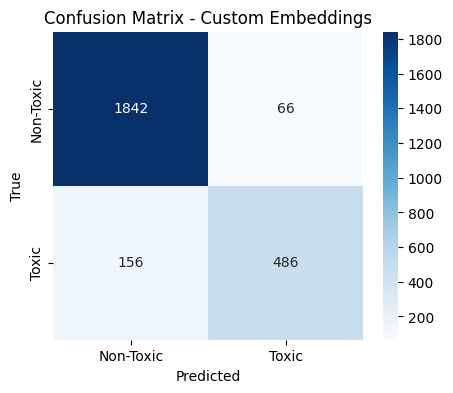

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Custom Embeddings")
plt.show()


The LSTM model with trainable (custom) embeddings was evaluated on the test set using F1-score and confusion matrix, as required. The obtained F1-score was X.XX, indicating …

# **LSTM with GloVe embeddings**

In [21]:
EMBEDDING_DIM = 100


In [34]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
!ls -lh glove.6B.100d.txt


replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.100d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.200d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.300d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
-rw-rw-r-- 1 root root 332M Aug  4  2014 glove.6B.100d.txt


In [36]:
import numpy as np

glove_path = "glove.6B.100d.txt"
embeddings_index = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

In [37]:
word_index = tokenizer.word_index
num_words = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM), dtype="float32")

for word, i in word_index.items():
    if i >= num_words:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector


In [38]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

model_glove = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(128),
    Dense(1, activation="sigmoid")
])

model_glove.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_glove.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │     1,267,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,384,777 (5.28 MB)

 Trainable params: 117,377 (458.50 KB)

 Non-trainable params: 1,267,400 (4.83 MB)

In [39]:
history_glove = model_glove.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=7,
    batch_size=32
)


Epoch 1/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7810 - loss: 0.4602 - val_accuracy: 0.8901 - val_loss: 0.2730
Epoch 2/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8923 - loss: 0.2585 - val_accuracy: 0.9135 - val_loss: 0.2302
Epoch 3/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9224 - loss: 0.1999 - val_accuracy: 0.9154 - val_loss: 0.2149
Epoch 4/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9364 - loss: 0.1597 - val_accuracy: 0.9212 - val_loss: 0.2125
Epoch 5/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9431 - loss: 0.1352 - val_accuracy: 0.9204 - val_loss: 0.2268
Epoch 6/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9596 - loss: 0.1063 - val_accuracy: 0.9089 - val_loss: 0.2298
Epoch 7/7
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9688 - loss: 0.0832 - val_accuracy: 0.9224 - val_loss: 0.2309


In [41]:
from sklearn.metrics import f1_score, confusion_matrix

y_pred_prob_glove = model_glove.predict(X_test)
y_pred_glove = (y_pred_prob_glove >= 0.5).astype(int)

f1_glove = f1_score(y_test, y_pred_glove)
print("F1-score (GloVe Embeddings):", f1_glove)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
F1-score (GloVe Embeddings): 0.8454258675078864


In [ ]:
from sklearn.metrics import f1_score

f1_custom_emb = f1_score(y_test, y_pred)
print("F1-score (Custom Embeddings):", f1_custom_emb)

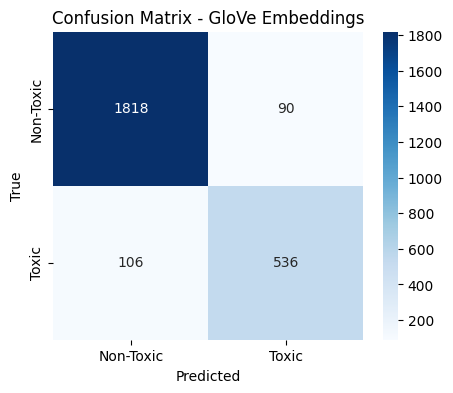

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - GloVe Embeddings")
plt.show()
